### Initialize paths

In [ ]:
from pathlib import Path

# Subject ID
subid = "0001"

# Base directories
udel_dir = Path("/home/oana/UDel")
udel_subj = udel_dir/f"U01_UDEL_{subid}_01_v3"
udel_anatomy = udel_subj/f"U01_UDEL_{subid}_01_SLANT"
fs_dir = udel_dir / "fsruns" / subid
mre_dir = Path("/home/oana/MRE_analysis") / subid


# MRE volumes
mre_files = {
    "stiffness": mre_dir / "MRE_stiffness_in_T1_space.nii.gz",
    "real": mre_dir / "MRE_real_in_T1_space.nii.gz",
    "imag": mre_dir / "MRE_imag_in_T1_space.nii.gz",
}

# T1W and T2w paths for myelin calculation
t1w_path = mre_dir/"T1_MNI_in_fs_space.nii.gz"
t2w_path = mre_dir/"T2_MNI_in_fs_space.nii.gz"

# Brain mask
brainmask_path = mre_dir /"brainmask_fs.nii.gz"



### Surface sampling

In [ ]:
import numpy as np
import nibabel as nib
from cortech import Cortex
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

cortex = Cortex.from_freesurfer_subject_dir(fs_dir, pial="pial.T1", registration="sphere.reg")

# smooth white/pial surfaces
#for hemi in [cortex.lh, cortex.rh]:
#    hemi.white.smooth_taubin(n_iter=5, inplace=True)
#    hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# estimate central surface
mid_layers = {
    "lh": cortex.lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
    "rh": cortex.rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
}

# interpolate all MRE data
surface_mre = {}

for name, vol_path in mre_files.items():
    img = nib.load(str(vol_path))
    data = img.get_fdata()
    affine = img.affine

    surface_mre[name] = {hemi: mid_layers[hemi].interpolate_to_nodes(data, affine) for hemi in ["lh", "rh"]}


# Myelin map
t1_img = nib.load(str(t1w_path))
t2_img = nib.load(str(t2w_path))
#mask_img = nib.load(str(brainmask_path))

t1_data = t1_img.get_fdata()
t2_data = t2_img.get_fdata()
#mask_data = mask_img.get_fdata().astype(bool)

t1_affine = t1_img.affine

mask_img = nib.load(str(brainmask_path))
mask_data = mask_img.get_fdata()
mask_binary = mask_data > 0  # inside brain 

t1_masked = np.where(mask_binary, t1_data, 0)
t2_masked = np.where(mask_binary, t2_data, 0)

#compute ratio only there both images arep positive
valid = (t1_masked > 0) & (t2_masked > 0)
myelin_data = np.where(valid, t1_masked/(t2_masked + 1e-3), 0)

# Interpolate myelin map to surface
surface_myelin = {hemi: mid_layers[hemi].interpolate_to_nodes(myelin_data, t1_affine) for hemi in ["lh", "rh"]}


#Add geometry parameters

from nibabel.freesurfer import read_morph_data

curvature = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.curv"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.curv"),
}


thickness = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.thickness"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.thickness"),
}

sulcal_depth = {
    "lh": read_morph_data(fs_dir / "surf" / "lh.sulc"),
    "rh": read_morph_data(fs_dir / "surf" / "rh.sulc"),
}


In [36]:
myelinimage=nib.Nifti1Image(myelin_data,t1_affine)
nib.save(myelinimage,mre_dir/'Myelin.nii.gz')

In [13]:
for hemi in ["lh","rh"]:
    arr=surface_myelin[hemi]
    print(hemi, np.min(arr), np.max(arr), np.mean(arr))

lh -0.25594497567634883 12.716348859852477 0.480480032446488
rh -0.0257530824743289 4.72597447730459 0.487232153949122


### Vertex-wise descriptive statistics and visualization 

In [37]:
import pandas as pd

stiff_min=99 #Pa (=0.09 kPa)

for hemi in ["lh","rh"]:
    #Extract hemi specific arrays
    curv = curvature[hemi].astype(np.float64)
    thick= thickness[hemi].astype(np.float64)
    stiff = surface_mre["stiffness"][hemi].astype(np.float64)
    real = surface_mre["real"][hemi].astype(np.float64) #shear real (storage modulus)
    imag = surface_mre["imag"][hemi].astype(np.float64) #shear imaginar (loss modulus)
    sulc =sulcal_depth[hemi].astype(np.float64)
    myelin = surface_myelin[hemi].astype(np.float64)

    #Stiffness mask that eliminates values around zero
    stiff_mask=(np.isfinite(stiff) & (stiff >= stiff_min))

    #Apply the mask to the other 
    curv_m=curv[stiff_mask]
    thick_m=thick[stiff_mask]
    stiff_m = stiff[stiff_mask]
    real_m =real[stiff_mask]
    imag_m = imag[stiff_mask]
    sulc_m =sulc[stiff_mask]
    myelin_m=myelin[stiff_mask]

    #Check values
    print(f"Initial vertices {hemi.upper()}:",len(stiff), f"({len(myelin)== len(imag) & len(stiff)==len(curv)})")
    print(f"After filtering vertices {hemi.upper()}:",len(stiff_m), f"({len(myelin_m)== len(imag_m) & len(stiff_m)==len(curv_m)})")

    #Transform shear stiffness, storage modulus and loss modulus to kPa
    stiff_kpa = stiff_m/1000
    real_kpa = real_m/1000
    imag_kpa = imag_m/1000

    #Create a DataFrame 
    df = pd.DataFrame({
        "curvature":curv_m,
        "thickness":thick_m,
        "sulcal_depth":sulc_m,
        "stiffness":stiff_kpa,
        "real":real_kpa,
        "imag":imag_kpa,
        "myelin":myelin_m,
    })

df.describe()

    


Initial vertices LH: 158340 (True)
After filtering vertices LH: 152319 (True)
Initial vertices RH: 159948 (True)
After filtering vertices RH: 153716 (True)


,curvature,thickness,sulcal_depth,stiffness,real,imag,myelin
count,153716.000000,153716.000000,153716.000000,153716.000000,153716.000000,153716.000000,153716.000000
mean,-0.021281,2.393531,0.250125,2.833257,2.399141,1.074870,0.488045
std,0.160836,0.906560,5.548738,0.856127,0.884726,0.461676,0.124143
min,-0.643204,0.000000,-14.329679,0.099035,0.025242,0.000707,-0.025753
25%,-0.138074,1.960080,-4.011983,2.340931,1.831647,0.774613,0.420309
50%,0.001130,2.479377,-0.128173,2.808097,2.332951,1.115679,0.473495
75%,0.108364,2.973067,4.238065,3.352004,2.925332,1.391897,0.538002
max,0.430637,5.000000,16.251078,6.289461,6.239851,2.699844,4.725974


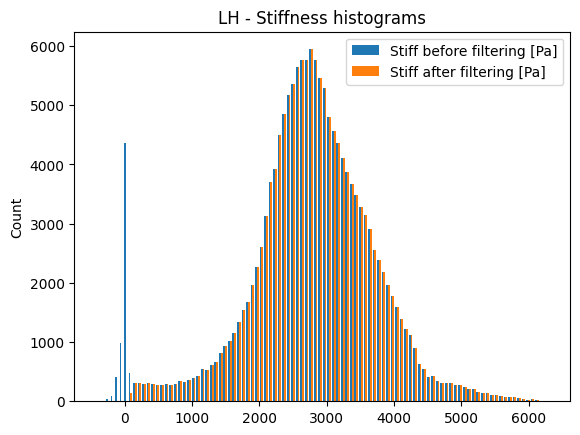

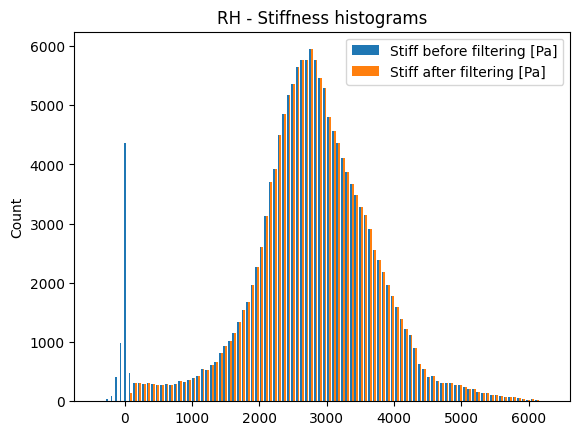

In [38]:

for hemi in ["lh","rh"]:
    plt.hist([stiff, stiff_m], bins=100, label=["Stiff before filtering [Pa]","Stiff after filtering [Pa]"])
    plt.ylabel("Count")
    plt.title(f"{hemi.upper()} - Stiffness histograms")
    plt.legend()
    plt.show()



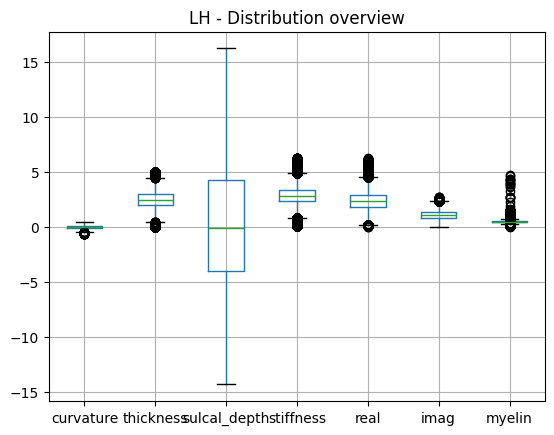

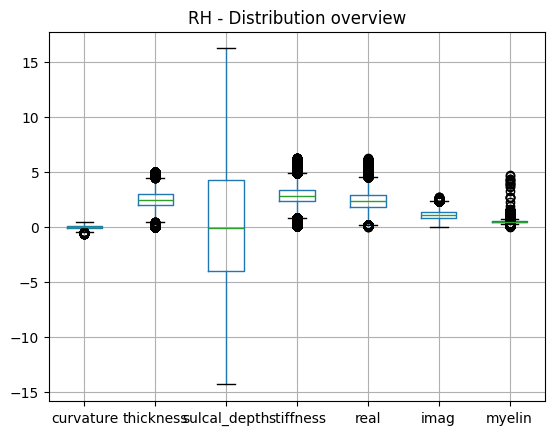

In [39]:
import matplotlib.pyplot as plt
for hemi in ["lh","rh"]:
    df.boxplot()
    plt.title(f"{hemi.upper()} - Distribution overview")
    plt.show()


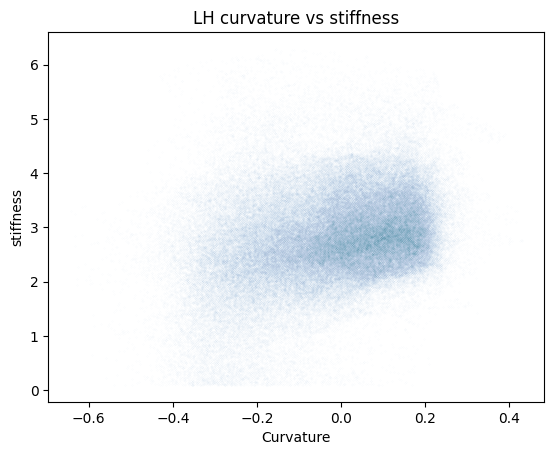

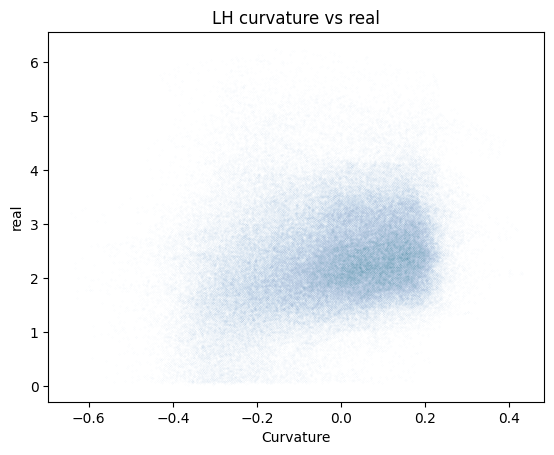

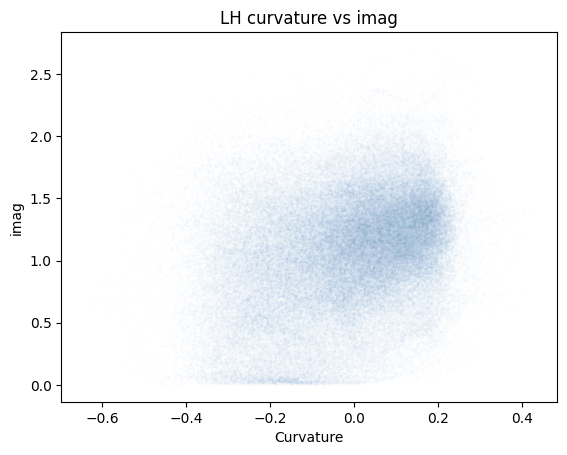

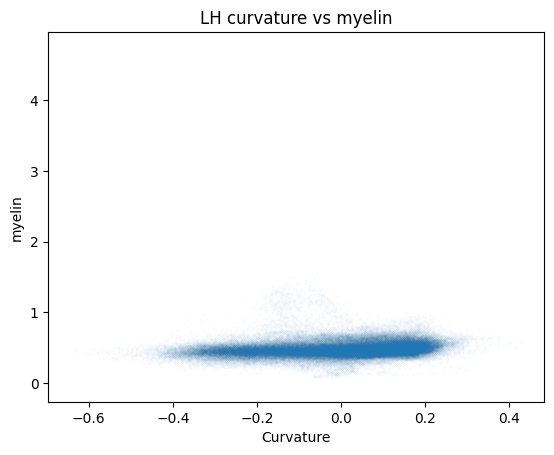

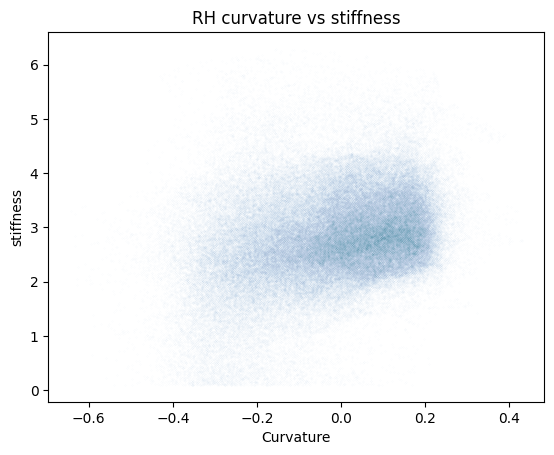

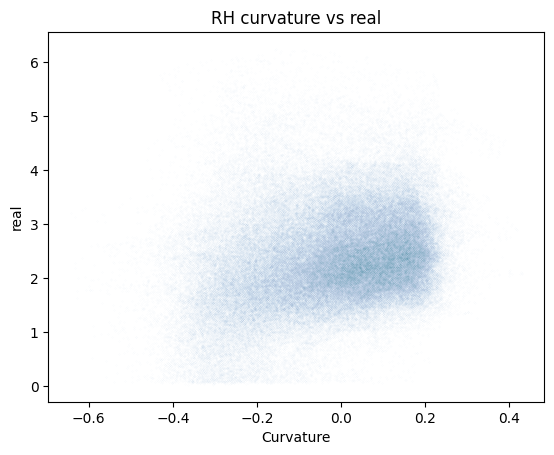

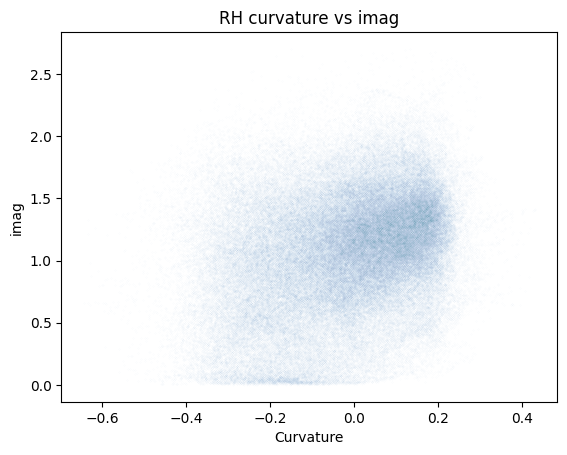

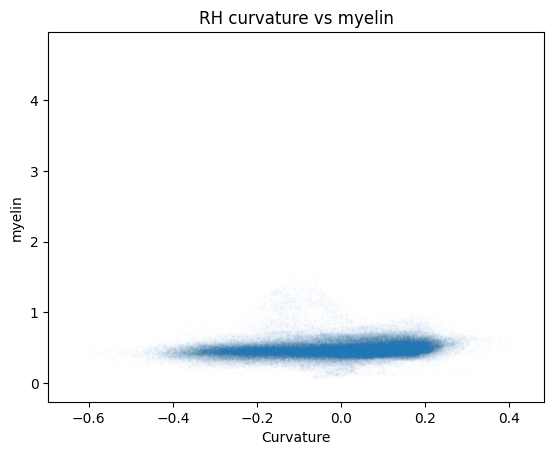

In [40]:
for hemi in ["lh","rh"]:
    for prop in ["stiffness","real","imag","myelin"]:
        plt.scatter(df["curvature"], df[prop], s=0.0001)
        plt.xlabel("Curvature")
        plt.ylabel(prop)
        plt.title (f"{hemi.upper()} curvature vs {prop}")
        plt.show()

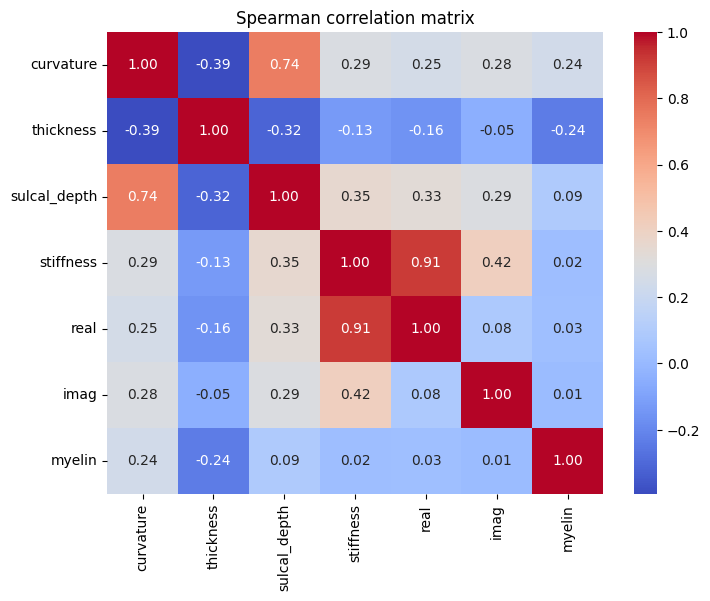

In [41]:
import seaborn as sns

corr_s =df.corr(method="spearman")
plt.figure(figsize=(8,6))
sns.heatmap(corr_s, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman correlation matrix")
plt.show()


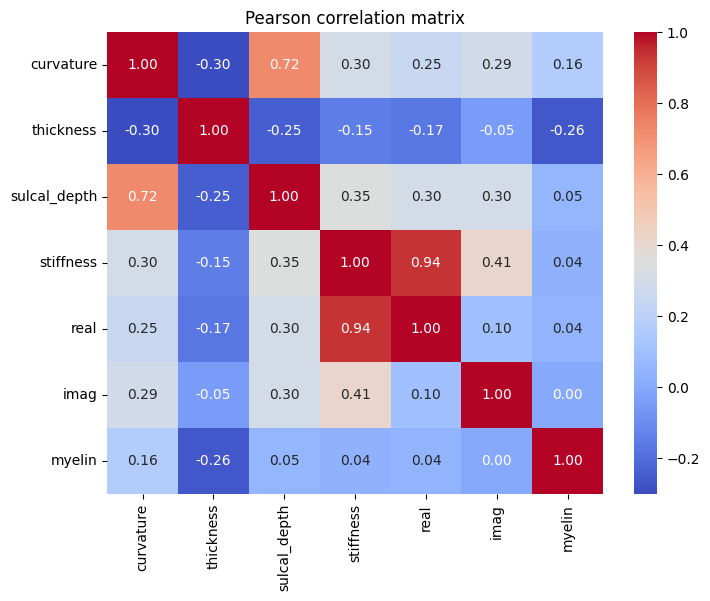

In [42]:
corr_p =df.corr(method="pearson")
plt.figure(figsize=(8,6))
sns.heatmap(corr_p, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson correlation matrix")
plt.show()

In [43]:
from scipy.stats import pearsonr, spearmanr

results = {}
# Correlations with curvature
for hemi in ["lh", "rh"]:
    results[hemi] = {}
    for prop in ["stiffness", "real", "imag","myelin"]:
        #Curvature
        r_p, p_p =pearsonr(df[prop], df["curvature"])
        r_s, p_s =spearmanr(df[prop], df["curvature"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs curvature \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")

        #Thickness

        r_p, p_p =pearsonr(df[prop], df["thickness"])
        r_s, p_s =spearmanr(df[prop], df["thickness"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs thicnkess \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")



        r_p, p_p =pearsonr(df[prop], df["sulcal_depth"])
        r_s, p_s =spearmanr(df[prop], df["sulcal_depth"])

        results[hemi][prop] = {"pearson_r": r_p, "pearson_p": p_p, "spearman_r": r_s, "spearman_p": p_s}

        print(f"{hemi.upper()} {prop} vs sulcal depth \n Pearson r={r_p:.3f}, p={p_p:.2e} \n Spearman r={r_s:.3f}, p={p_s:.2e}")



LH stiffness vs curvature 
 Pearson r=0.302, p=0.00e+00 
 Spearman r=0.287, p=0.00e+00
LH stiffness vs thicnkess 
 Pearson r=-0.152, p=0.00e+00 
 Spearman r=-0.130, p=0.00e+00
LH stiffness vs sulcal depth 
 Pearson r=0.348, p=0.00e+00 
 Spearman r=0.353, p=0.00e+00
LH real vs curvature 
 Pearson r=0.249, p=0.00e+00 
 Spearman r=0.251, p=0.00e+00
LH real vs thicnkess 
 Pearson r=-0.169, p=0.00e+00 
 Spearman r=-0.158, p=0.00e+00
LH real vs sulcal depth 
 Pearson r=0.300, p=0.00e+00 
 Spearman r=0.325, p=0.00e+00
LH imag vs curvature 
 Pearson r=0.290, p=0.00e+00 
 Spearman r=0.283, p=0.00e+00
LH imag vs thicnkess 
 Pearson r=-0.048, p=1.11e-77 
 Spearman r=-0.046, p=1.13e-72
LH imag vs sulcal depth 
 Pearson r=0.304, p=0.00e+00 
 Spearman r=0.292, p=0.00e+00
LH myelin vs curvature 
 Pearson r=0.163, p=0.00e+00 
 Spearman r=0.240, p=0.00e+00
LH myelin vs thicnkess 
 Pearson r=-0.265, p=0.00e+00 
 Spearman r=-0.238, p=0.00e+00
LH myelin vs sulcal depth 
 Pearson r=0.050, p=3.51e-87 
 Spea

In [44]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["curvature"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere: curvature ~ stiffness")
    print(model.summary())


LH hemisphere: curvature ~ stiffness
                            OLS Regression Results                            
Dep. Variable:              curvature   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                 1.541e+04
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:22:37   Log-Likelihood:                 70126.
No. Observations:              153716   AIC:                        -1.402e+05
Df Residuals:                  153714   BIC:                        -1.402e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

In [45]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["curvature"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: curvature ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere multiple regression: curvature ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:              curvature   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     8076.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:22:45   Log-Likelihood:                 77443.
No. Observations:              153716   AIC:                        -1.549e+05
Df Residuals:                  153711   BIC:                        -1.548e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [46]:
for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["sulcal_depth"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: sulcal_depth ~ stiffness")
    print(model.summary())


LH hemisphere multiple regression: sulcal_depth ~ stiffness
                            OLS Regression Results                            
Dep. Variable:           sulcal_depth   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                 2.112e+04
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:22:49   Log-Likelihood:            -4.7162e+05
No. Observations:              153716   AIC:                         9.432e+05
Df Residuals:                  153714   BIC:                         9.433e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [47]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["sulcal_depth"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere: sulcal_depth ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere: sulcal_depth ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:           sulcal_depth   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.199
Method:                 Least Squares   F-statistic:                     9522.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:22:53   Log-Likelihood:            -4.6450e+05
No. Observations:              153716   AIC:                         9.290e+05
Df Residuals:                  153711   BIC:                         9.291e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [48]:
for hemi in ["lh", "rh"]:
    x = df[["stiffness"]] #predictors
    y = df["thickness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: thickness~ stiffness")
    print(model.summary())


LH hemisphere multiple regression: thickness~ stiffness
                            OLS Regression Results                            
Dep. Variable:              thickness   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     3629.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:22:57   Log-Likelihood:            -2.0124e+05
No. Observations:              153716   AIC:                         4.025e+05
Df Residuals:                  153714   BIC:                         4.025e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [49]:
import statsmodels.api as sm

for hemi in ["lh", "rh"]:
    x = df[["stiffness","real","imag","myelin"]] #predictors
    y = df["thickness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: thickness ~ stiffness + real + imag + myelin")
    print(model.summary())


LH hemisphere multiple regression: thickness ~ stiffness + real + imag + myelin
                            OLS Regression Results                            
Dep. Variable:              thickness   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     4735.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:23:02   Log-Likelihood:            -1.9410e+05
No. Observations:              153716   AIC:                         3.882e+05
Df Residuals:                  153711   BIC:                         3.883e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [50]:
for hemi in ["lh", "rh"]:
    x = df[["curvature","thickness","sulcal_depth"]] #predictors
    y = df["stiffness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth")
    print(model.summary())


LH hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth
                            OLS Regression Results                            
Dep. Variable:              stiffness   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     7598.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:23:07   Log-Likelihood:            -1.8361e+05
No. Observations:              153716   AIC:                         3.672e+05
Df Residuals:                  153712   BIC:                         3.673e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

In [51]:
for hemi in ["lh", "rh"]:
    x = df[["curvature","thickness","sulcal_depth","myelin"]] #predictors
    y = df["stiffness"] #outcome

    x=sm.add_constant(x)

    model = sm.OLS(y,x).fit()

    print(f"\n{hemi.upper()} hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth + myelin")
    print(model.summary())


LH hemisphere multiple regression: stiffness ~ curvature + thickness + sulcal_depth + myelin
                            OLS Regression Results                            
Dep. Variable:              stiffness   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     5703.
Date:                Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:23:12   Log-Likelihood:            -1.8360e+05
No. Observations:              153716   AIC:                         3.672e+05
Df Residuals:                  153711   BIC:                         3.673e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

### Older results. Descriptive statistics and visualization

In [3]:
import pandas as pd
import numpy as np

hemi = "lh"  

df = pd.DataFrame({
    "curvature": curvature[hemi].astype(np.float64),
    "thickness": thickness[hemi].astype(np.float64),
    "stiffness": surface_mre["stiffness"][hemi].astype(np.float64),
    "real": surface_mre["real"][hemi].astype(np.float64),
    "imag": surface_mre["imag"][hemi].astype(np.float64),
})

#print(df.shape)
df.describe()


,curvature,thickness,stiffness,real,imag
count,158340.000000,158340.000000,158340.000000,158340.000000,158340.000000
mean,-0.026913,2.462159,2733.602002,2309.713066,1058.668951
std,0.163726,0.888901,999.673563,956.850657,501.190255
min,-0.856185,0.000000,-461.241033,-334.362891,-282.743347
25%,-0.149552,2.047178,2255.763151,1796.490517,764.085793
50%,-0.007015,2.547948,2784.109101,2299.049782,1093.793066
75%,0.105609,3.024685,3366.749733,2877.801402,1387.493890
max,0.613034,5.000000,6503.876975,6454.599686,2810.972780


In [4]:
from scipy.stats import describe

desc = describe(df, axis=0)
#print(desc)
pd.DataFrame({
    "mean": desc.mean,
    "variance": desc.variance,
    "min": desc.minmax[0],
    "max": desc.minmax[1],
    "skewness": desc.skewness,
    "kurtosis": desc.kurtosis,
}, index=df.columns)



,mean,variance,min,max,skewness,kurtosis
curvature,-0.026913,0.026806,-0.856185,0.613034,-0.366335,-0.622449
thickness,2.462159,0.790145,0.000000,5.000000,-0.854616,1.346626
stiffness,2733.602002,999347.231916,-461.241033,6503.876975,-0.635364,1.143584
real,2309.713066,915563.180061,-334.362891,6454.599686,-0.089052,0.769261
imag,1058.668951,251191.672115,-282.743347,2810.972780,-0.192038,-0.143223


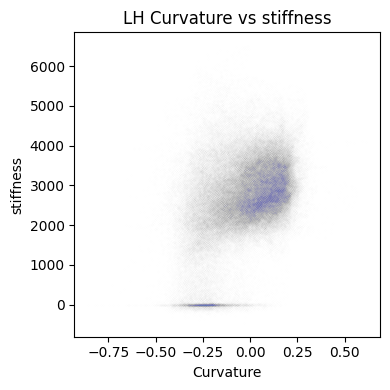

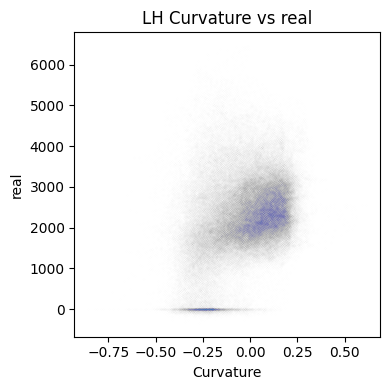

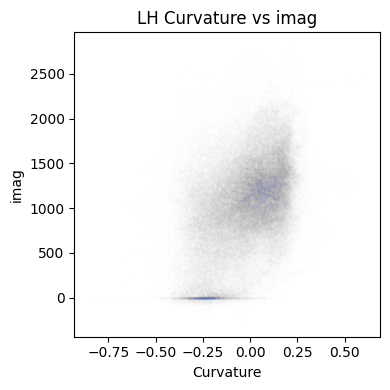

In [5]:
for prop in ["stiffness", "real", "imag"]:
    plt.figure(figsize=(4,4))
    plt.scatter(df["curvature"], df[prop], s=0.0001, alpha=0.3)
    plt.xlabel("Curvature")
    plt.ylabel(prop)
    plt.title(f"{hemi.upper()} Curvature vs {prop}")
    plt.tight_layout()
    plt.show()


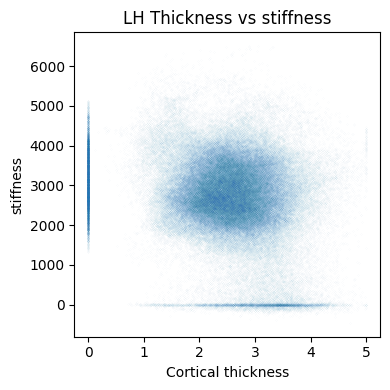

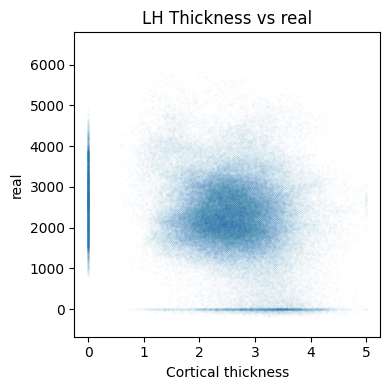

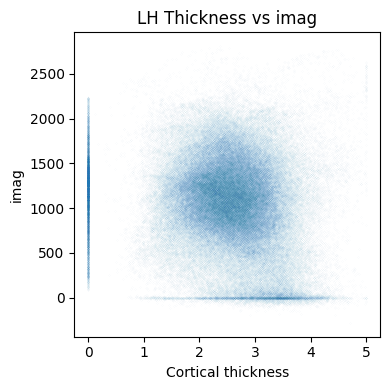

In [6]:
for prop in ["stiffness", "real", "imag"]:
    plt.figure(figsize=(4,4))
    plt.scatter(df["thickness"], df[prop], s=0.001, alpha=0.3)
    plt.xlabel("Cortical thickness")
    plt.ylabel(prop)
    plt.title(f"{hemi.upper()} Thickness vs {prop}")
    plt.tight_layout()
    plt.show()


In [7]:
df.corr(method="spearman")

,curvature,thickness,stiffness,real,imag
curvature,1.000000,-0.379909,0.347604,0.297456,0.397703
thickness,-0.379909,1.000000,-0.165889,-0.159946,-0.159595
stiffness,0.347604,-0.165889,1.000000,0.926928,0.534943
real,0.297456,-0.159946,0.926928,1.000000,0.256248
imag,0.397703,-0.159595,0.534943,0.256248,1.000000


In [8]:
df.corr(method="pearson")

,curvature,thickness,stiffness,real,imag
curvature,1.000000,-0.289677,0.381117,0.310846,0.415994
thickness,-0.289677,1.000000,-0.212603,-0.202224,-0.156096
stiffness,0.381117,-0.212603,1.000000,0.950643,0.586138
real,0.310846,-0.202224,0.950643,1.000000,0.324186
imag,0.415994,-0.156096,0.586138,0.324186,1.000000


### Correlation analysis

In [9]:
from scipy.stats import pearsonr, spearmanr
import numpy as np

#mask = surface_brainmask[hemi]
def clean_pair(x, y):
    mask = (
        np.isfinite(x) &
        np.isfinite(y) 
    )
    #return x[mask], y[mask]
    return x, y

results = {}
# Correlations with curvature
for hemi in ["lh", "rh"]:
    results[hemi] = {}

    curv = curvature[hemi]

    for prop in ["stiffness", "real", "imag"]:
        mre = surface_mre[prop][hemi]

        x, y = clean_pair(curv, mre)

        r_p, p_p = pearsonr(x, y)
        r_s, p_s = spearmanr(x, y)

        results[hemi][prop] = {
            "N": len(x),
            "pearson_r": r_p,
            "pearson_p": p_p,
            "spearman_r": r_s,
            "spearman_p": p_s
        }

        print(
            f"{hemi.upper()} | {prop} | N={len(x)} | "
            f"Pearson r={r_p:.3f}, p={p_p:.2e} | "
            f"Spearman r={r_s:.3f}, p={p_s:.2e}"
        )


LH | stiffness | N=158340 | Pearson r=0.381, p=0.00e+00 | Spearman r=0.348, p=0.00e+00
LH | real | N=158340 | Pearson r=0.311, p=0.00e+00 | Spearman r=0.297, p=0.00e+00
LH | imag | N=158340 | Pearson r=0.416, p=0.00e+00 | Spearman r=0.398, p=0.00e+00
RH | stiffness | N=159948 | Pearson r=0.369, p=0.00e+00 | Spearman r=0.336, p=0.00e+00
RH | real | N=159948 | Pearson r=0.319, p=0.00e+00 | Spearman r=0.303, p=0.00e+00
RH | imag | N=159948 | Pearson r=0.350, p=0.00e+00 | Spearman r=0.332, p=0.00e+00


In [10]:
# Correlations with thickness
for hemi in ["lh", "rh"]:
    thick = thickness[hemi]

    for prop in ["stiffness", "real", "imag"]:
        mre = surface_mre[prop][hemi]

        x, y = clean_pair(thick, mre)

        r_p, p_p = pearsonr(x, y)
        r_s, p_s = spearmanr(x, y)

        results[hemi][prop + "_thickness"] = {
            "N": len(x),
            "pearson_r": r_p,
            "pearson_p": p_p,
            "spearman_r": r_s,
            "spearman_p": p_s
        }

        print(
            f"{hemi.upper()} | {prop} | N={len(x)} | "
            f"Pearson r={r_p:.3f}, p={p_p:.2e} | "
            f"Spearman r={r_s:.3f}, p={p_s:.2e} (thickness)"
        )


LH | stiffness | N=158340 | Pearson r=-0.213, p=0.00e+00 | Spearman r=-0.166, p=0.00e+00 (thickness)
LH | real | N=158340 | Pearson r=-0.202, p=0.00e+00 | Spearman r=-0.160, p=0.00e+00 (thickness)
LH | imag | N=158340 | Pearson r=-0.156, p=0.00e+00 | Spearman r=-0.160, p=0.00e+00 (thickness)
RH | stiffness | N=159948 | Pearson r=-0.190, p=0.00e+00 | Spearman r=-0.160, p=0.00e+00 (thickness)
RH | real | N=159948 | Pearson r=-0.202, p=0.00e+00 | Spearman r=-0.185, p=0.00e+00 (thickness)
RH | imag | N=159948 | Pearson r=-0.093, p=8.53e-307 | Spearman r=-0.084, p=4.20e-248 (thickness)
